# Clustering Semantico dei Report di Insicurezza Alimentare (IPC)

Questo notebook implementa una pipeline avanzata per il caricamento, la pulizia, l'embedding denso e il clustering semantico dei report IPC.  
L'obiettivo è raggruppare le situazioni di crisi in base alla tipologia di insicurezza alimentare e ai driver che le causano (es. conflitti, siccità, crisi economiche), indipendentemente dal paese.

La pipeline è progettata per essere eseguita sulla **GPU di Google Colab** e include:
1. Setup dell'ambiente (Montaggio Drive e installazione delle librerie).
2. Caricamento e pulizia dei testi (rimozione dell'intestazione metadati).
3. Generazione di embedding con **Instructor-Large** (`hkunlp/instructor-large`), un modello avanzato esplicitamente ottimizzato per seguire istruzioni arbitrarie per compiti come il clustering.
4. Riduzione dimensionale con **UMAP** (5D per clustering, 2D per visualizzazione).
5. Clustering con **K-Means** (e scelta ottimale di K con metriche geometriche come *Silhouette Score* e *Davies-Bouldin Index*) e **HDBSCAN**.
6. **Validazione della Coerenza Semantica**:
   - **Lemmatizzazione (NLTK)** e rimozione dei nomi dei paesi nel TF-IDF per parole chiave pulite.
   - **Tabella di Contingenza** (Paese vs. Cluster) ed entropia geografica per escludere il bias geografico.
   - **LLM-as-a-Judge** (tramite API Mistral) per descrivere i cluster e valutarne la coerenza semantica.
7. Visualizzazione interattiva 2D con **Plotly**.

## 1. Setup dell'Ambiente e Importazione Librerie

In [2]:
import pandas as pd
df = pd.read_csv("df_duplicati.csv")
df

,Unnamed: 0,nome_file,paese,periodo,inizio_periodo,fine_periodo,testo_originale,gruppo,Llama_3_2_3B_anonimo,Llama_3_1_8B_anonimo,Llama_3_1_8B_8bit_anonimo
0,7,El_Salvador_Mar_2025_-_Feb_2026_KeyResults.txt,El Salvador,Mar 2025 / Feb 2026,Mar 2025,Feb 2026,"During the current period (March to May 2025),...",0.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe affected areas are...,[SHOCKS AND DRIVERS]:\nThe affected areas are ...
1,9,Honduras_Mar_2025_-_Feb_2026_KeyResults.txt,Honduras,Mar 2025 / Feb 2026,Mar 2025,Feb 2026,"During the current period (March to May 2025),...",0.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe affected areas are...,[SHOCKS AND DRIVERS]:\nThe affected areas are ...
2,23,Guatemala_Mar_2025_-_Feb_2026_KeyResults.txt,Guatemala,Mar 2025 / Feb 2026,Mar 2025,Feb 2026,"During the current period (March to May 2025),...",0.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe affected areas are...,[SHOCKS AND DRIVERS]: \nThe affected areas are...
3,31,El_Salvador_Jun_2020_-_Aug_2020_KeyResults.txt,El Salvador,Jun 2020 / Aug 2020,Jun 2020,Aug 2020,"Overview\nFrom June to August 2020, the period...",1.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,"[SHOCKS AND DRIVERS]:\nEconomic factors, clima..."
4,35,Honduras_Jun_2020_-_Aug_2020_KeyResults.txt,Honduras,Jun 2020 / Aug 2020,Jun 2020,Aug 2020,"Overview\nFrom June to August 2020, the period...",1.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]:\nThe affected areas are ...
5,59,Guatemala_Jun_2020_-_Aug_2020_KeyResults.txt,Guatemala,Jun 2020 / Aug 2020,Jun 2020,Aug 2020,"Overview\nFrom June to August 2020, the period...",1.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,"[SHOCKS AND DRIVERS]:\nEconomic factors, clima..."
6,68,El_Salvador_Jun_2022_-_Aug_2022_KeyResults.txt,El Salvador,Jun 2022 / Aug 2022,Jun 2022,Aug 2022,Since several months have passed since the sec...,2.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...
7,70,Honduras_Jun_2022_-_Aug_2022_KeyResults.txt,Honduras,Jun 2022 / Aug 2022,Jun 2022,Aug 2022,Since several months have passed since the sec...,2.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...
8,74,Guatemala_Jun_2022_-_Aug_2022_KeyResults.txt,Guatemala,Jun 2022 / Aug 2022,Jun 2022,Aug 2022,Since several months have passed since the sec...,2.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...
9,162,El_Salvador_Nov_2018_-_Apr_2019_KeyResults.txt,El Salvador,Nov 2018 / Apr 2019,Nov 2018,Apr 2019,The Tri-national Border Federation of Río Lemp...,3.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...


In [3]:
# 1.1 Monta Google Drive per accedere ai file dei report
#from google.colab import drive
import os
import pandas as pd
#drive.mount('/content/drive')

# Definisci il percorso della cartella contenente i report in formato .txt
# Modifica questo percorso se la tua cartella si trova altrove su Drive
DRIVE_PATH = "./"
#
TESTO_DIR = df["Llama_3_1_8B_anonimo"]
#
#print(f"Directory dei report impostata su: {TESTO_DIR}")
#if os.path.exists(TESTO_DIR):
#    print(f"Trovati {len(os.listdir(TESTO_DIR))} elementi nella cartella.")
#else:
#    print("ATTENZIONE: Il percorso specificato non esiste. Verifica che Google Drive sia montato correttamente.")

In [4]:
# 1.3 Import delle librerie necessarie
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import pairwise_distances_argmin_min
import plotly.express as px
import torch
import scipy.stats as stats
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Impostiamo il seed per la riproducibilità dei risultati
np.random.seed(42)

# Download delle risorse NLTK per la lemmatizzazione
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet = True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('stopwords', quiet=True)
print("NLTK e librerie importate correttamente.")

/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NLTK e librerie importate correttamente.


## 2. Caricamento e Pulizia dei Dati

Leggiamo i 497 report testuali. Estraiamo dal nome del file il Paese e il Periodo, dopodiché puliamo il testo utile eliminando la testata dei metadati (tutto ciò che precede la riga divisoria con `========================================`).

In [5]:
# 2.1 Funzione per estrarre metadati dal nome del file
'''
def estrai_metadata(nome_file):
    base = nome_file.replace("_KeyResults.txt", "")

    # Cerca il pattern del periodo: Mese_Anno_-_Mese_Anno (es. Apr_2016_-_Dec_2016)
    periodo_match = re.search(r'([A-Za-z]{3}_\d{4})_-_([A-Za-z]{3}_\d{4})', base)

    if periodo_match:
        inizio_periodo = periodo_match.group(1).replace('_', ' ')  # es. "Apr 2016"
        fine_periodo = periodo_match.group(2).replace('_', ' ')    # es. "Dec 2016"
        periodo = f"{inizio_periodo} / {fine_periodo}"
    else:
        inizio_periodo = None
        fine_periodo = None
        periodo = base.replace('_', ' ')

    # Paese: tutto quello che precede il primo mese o anno
    paese_match = re.match(r'^(.+?)_[A-Za-z]{3}_\d{4}', base)
    paese = paese_match.group(1).replace('_', ' ') if paese_match else base.replace('_', ' ')

    return {
        "paese": paese,
        "periodo": periodo,
        "inizio_periodo": inizio_periodo,
        "fine_periodo": fine_periodo,
        "nome_file": nome_file
    }

# 2.2 Caricamento e pulizia dei report
files = [f for f in os.listdir(TESTO_DIR) if f.endswith(".txt")]
print(f"Trovati {len(files)} file .txt da elaborare.")

testi_puliti = []
metadata_list = []

for nome_file in files:
    path = os.path.join(TESTO_DIR, nome_file)
    with open(path, "r", encoding="utf-8") as f:
        testo_completo = f.read()

    # Rimuovi l'intestazione dei metadati (tutto ciò che precede la riga divisoria di '=' o '-')
    testo_pulito = re.sub(r'^.*?={20,}\n*', '', testo_completo, flags=re.DOTALL).strip()

    if not testo_pulito:
        print(f"Attenzione: il file {nome_file} è vuoto dopo la pulizia.")
        continue

    testi_puliti.append(testo_pulito)
    metadata_list.append(estrai_metadata(nome_file))

# Creazione del DataFrame
df = pd.DataFrame(metadata_list)
df["testo"] = testi_puliti
print(f"Caricati con successo {len(df)} report nel DataFrame.")
df.head()
'''

'\ndef estrai_metadata(nome_file):\n    base = nome_file.replace("_KeyResults.txt", "")\n\n    # Cerca il pattern del periodo: Mese_Anno_-_Mese_Anno (es. Apr_2016_-_Dec_2016)\n    periodo_match = re.search(r\'([A-Za-z]{3}_\\d{4})_-_([A-Za-z]{3}_\\d{4})\', base)\n\n    if periodo_match:\n        inizio_periodo = periodo_match.group(1).replace(\'_\', \' \')  # es. "Apr 2016"\n        fine_periodo = periodo_match.group(2).replace(\'_\', \' \')    # es. "Dec 2016"\n        periodo = f"{inizio_periodo} / {fine_periodo}"\n    else:\n        inizio_periodo = None\n        fine_periodo = None\n        periodo = base.replace(\'_\', \' \')\n\n    # Paese: tutto quello che precede il primo mese o anno\n    paese_match = re.match(r\'^(.+?)_[A-Za-z]{3}_\\d{4}\', base)\n    paese = paese_match.group(1).replace(\'_\', \' \') if paese_match else base.replace(\'_\', \' \')\n\n    return {\n        "paese": paese,\n        "periodo": periodo,\n        "inizio_periodo": inizio_periodo,\n        "fine_per

## 3. Generazione degli Embedding con Modello Instructor-Large (GPU)

Utilizziamo il modello **`hkunlp/instructor-large`**. Questo modello è stato esplicitamente addestrato per seguire istruzioni di testo arbitrarie per compiti come il clustering, formattate come coppie di `[istruzione, testo]`. Questo ci consente di guidare lo spazio semantico a focalizzarsi sui driver delle crisi e sulle condizioni di insicurezza alimentare.

In [6]:
# 3.1 Caricamento del modello Instructor-Large
# 3.1 Caricamento del modello GTE-Large
import torch
from sentence_transformers import SentenceTransformer
import einops

# 1. Rilevamento corretto dell'acceleratore Apple Silicon (Metal Performance Shaders)
MODEL_NAME = "nomic-ai/nomic-embed-text-v1.5"
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Caricamento modello {MODEL_NAME} su dispositivo: {device}...")

# 2. Inizializzazione con disattivazione del padding dinamico incompatibile con macOS
model = SentenceTransformer(
    MODEL_NAME,
    device=device,
    trust_remote_code=True,
)

# Definiamo l'istruzione per orientare il clustering esplicitamente sui driver
istruzione = "search_document: "

# Il modello GTE richiede la concatenazione diretta dell'istruzione e del testo
testi_con_istruzione = [istruzione + t for t in df["Llama_3_1_8B_anonimo"]]

print("Generazione degli embedding in corso...")
embeddings = model.encode(testi_con_istruzione, normalize_embeddings=True, show_progress_bar=True)
print(f"Embedding generati! Shape: {embeddings.shape}")

# Salva gli embedding su Drive per riutilizzarli senza rigenerarli
np.save(os.path.join(DRIVE_PATH, "embeddings_report_anonimi.npy"), embeddings)
df.to_parquet(os.path.join(DRIVE_PATH, "metadata_report_anonimi.parquet"))
print("Embedding e metadati salvati correttamente")

Caricamento modello nomic-ai/nomic-embed-text-v1.5 su dispositivo: mps...


<All keys matched successfully>


Generazione degli embedding in corso...


Batches: 100%|██████████| 2/2 [00:01<00:00,  1.19it/s]

Embedding generati! Shape: (35, 768)
Embedding e metadati salvati correttamente


## 4. Riduzione Dimensionale con UMAP

Riduciamo la dimensionalità degli embedding (768 dimensions) tramite UMAP:
- A **5 dimensioni** per ottimizzare l'esecuzione del clustering (evitando il problema delle distanze geometriche in alte dimensioni).
- A **2 dimensioni** solo per la successiva rappresentazione grafica sul piano cartesiano.

In [7]:
# 4.1 Riduzione dimensionale con UMAP
print("UMAP a 5 dimensioni per il clustering...")
reducer_clustering = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    n_components=5,
    metric="cosine",
    random_state=42
)
embeddings_5d = reducer_clustering.fit_transform(embeddings)

print("UMAP a 2 dimensioni per la visualizzazione...")
reducer_visualization = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)
embeddings_2d = reducer_visualization.fit_transform(embeddings)

# Inserimento coordinate UMAP nel dataframe
df["x"] = embeddings_2d[:, 0]
df["y"] = embeddings_2d[:, 1]

# Salva gli embedding ridotti
np.save(os.path.join(DRIVE_PATH, "embeddings_umap5d_report_anonimi.npy"), embeddings_5d)
print("Riduzione dimensionale completata e salvata.")

/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP a 5 dimensioni per il clustering...
UMAP a 2 dimensioni per la visualizzazione...
Riduzione dimensionale completata e salvata.


/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 5. Selezione ed Esecuzione del Clustering

### 5.1 Valutazione K-Means (Metodo del Gomito, Silhouette e Davies-Bouldin)

Per valutare il K ottimale analizziamo tre metriche:
1. **Inerzia (WCSS)**: la somma delle distanze quadrate dal centroide (cerca il "gomito").
2. **Silhouette Score**: misura quanto i punti sono vicini al proprio cluster e lontani dai vicini (più vicino a 1, meglio è).
3. **Davies-Bouldin Index**: misura la similarità media tra i cluster (valori più bassi indicano cluster più compatti e meglio separati).

/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.1

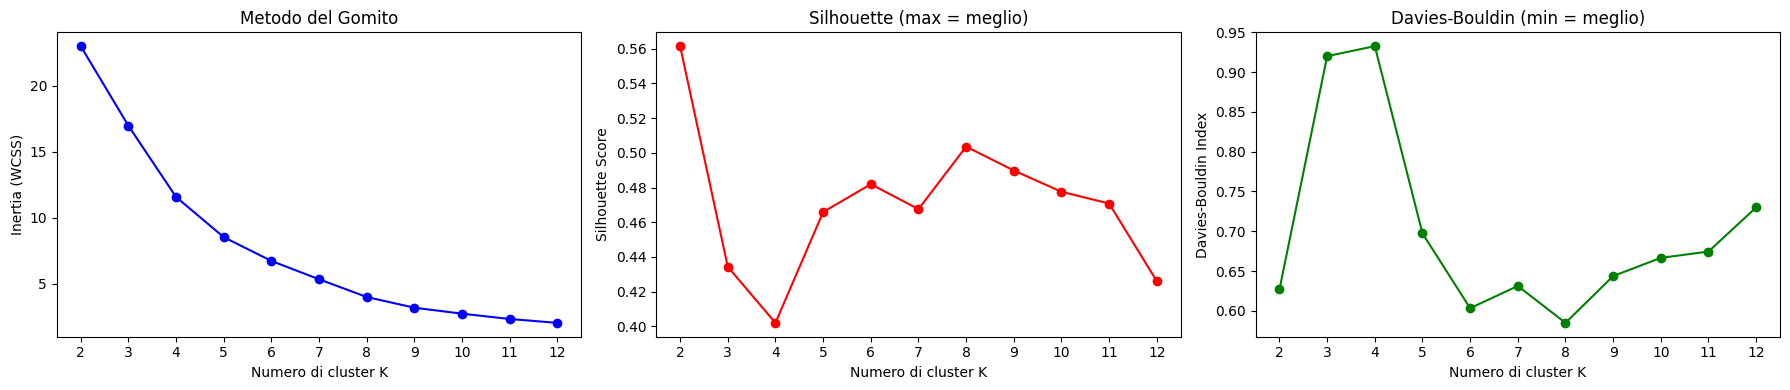

In [8]:
# 5.1.1 Valutazione geometrica su range di K
inertie = []
silhouette = []
davies_bouldin = []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings_5d)
    inertie.append(km.inertia_)
    silhouette.append(silhouette_score(embeddings_5d, labels))
    davies_bouldin.append(davies_bouldin_score(embeddings_5d, labels))

# Visualizzazione grafici di valutazione
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
ax1.plot(K_range, inertie, 'bo-')
ax1.set_xlabel('Numero di cluster K')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Metodo del Gomito')
ax1.set_xticks(K_range)

ax2.plot(K_range, silhouette, 'ro-')
ax2.set_xlabel('Numero di cluster K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette (max = meglio)')
ax2.set_xticks(K_range)

ax3.plot(K_range, davies_bouldin, 'go-')
ax3.set_xlabel('Numero di cluster K')
ax3.set_ylabel('Davies-Bouldin Index')
ax3.set_title('Davies-Bouldin (min = meglio)')
ax3.set_xticks(K_range)

plt.tight_layout()
plt.show()

### 5.2 Valutazione HDBSCAN (Clustering basato su densità)

Utilizziamo HDBSCAN come alternativa a K-Means per isolare cluster sferici irregolari ed escludere i punti anomali di "rumore" (indicati con -1).

In [9]:
# 5.2.1 Esecuzione HDBSCAN
import hdbscan

print("Calcolo dei cluster con HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="manhattan"
)
hdbscan_labels = clusterer.fit_predict(embeddings_5d)
df["cluster_hdbscan"] = hdbscan_labels

n_clusters_hdb = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise_hdb = list(hdbscan_labels).count(-1)

print(f"HDBSCAN ha individuato {n_clusters_hdb} cluster e ha classificato {n_noise_hdb} report come rumore (outlier).")

Calcolo dei cluster con HDBSCAN...
HDBSCAN ha individuato 0 cluster e ha classificato 35 report come rumore (outlier).


In [10]:
print(df["cluster_hdbscan"].value_counts())

cluster_hdbscan
-1    35
Name: count, dtype: int64


In [11]:
NUM_CLUSTERS = len(df['cluster_hdbscan'].unique())-1

for cluster_id in range(NUM_CLUSTERS):
    subset = df[df["cluster_hdbscan"] == cluster_id]
    print(f"\n=== CLUSTER {cluster_id} ({len(subset)} documenti) ===")
    print(subset[["paese", "inizio_periodo", "fine_periodo"]].to_string(index=False))

## 6. Interpretazione, Lemmatizzazione e Validazione dei Cluster

### 6.1 Clustering Finale K-Means

In [12]:
# 6.1.1 K-Means definitivo
K_SCELTO = 10 # Imposta manualmente qui il K desiderato (es. K_SCELTO = 5)

km_final = KMeans(n_clusters=K_SCELTO, random_state=42, n_init=10)
df["cluster_kmeans"] = km_final.fit_predict(embeddings_5d)

# Trova l'indice del report più vicino al centroide per ciascun cluster
indici_piu_vicini, _ = pairwise_distances_argmin_min(km_final.cluster_centers_, embeddings_5d)

In [13]:
# ============================================================
# STEP 3: ESPLORA I CLUSTER
# ============================================================
for cluster_id in range(K_SCELTO):
    subset = df[df["cluster_kmeans"] == cluster_id]
    print(f"\n=== CLUSTER {cluster_id} ({len(subset)} documenti) ===")
    print(subset[["paese", "inizio_periodo", "fine_periodo"]].to_string(index=False))


=== CLUSTER 0 (3 documenti) ===
      paese inizio_periodo fine_periodo
  Guatemala       Nov 2021     Aug 2022
   Honduras       Nov 2021     Aug 2022
El Salvador       Nov 2021     Aug 2022

=== CLUSTER 1 (3 documenti) ===
      paese inizio_periodo fine_periodo
   Honduras       Jun 2021     Aug 2021
El Salvador       Jun 2021     Aug 2021
  Guatemala       Jun 2021     Aug 2021

=== CLUSTER 2 (6 documenti) ===
      paese inizio_periodo fine_periodo
El Salvador       Nov 2018     Apr 2019
   Honduras       Nov 2018     Apr 2019
  Guatemala       Nov 2018     Apr 2019
  Guatemala       Feb 2018     Aug 2018
El Salvador       Feb 2018     Aug 2018
   Honduras       Feb 2018     Aug 2018

=== CLUSTER 3 (3 documenti) ===
      paese inizio_periodo fine_periodo
El Salvador       Mar 2025     Feb 2026
   Honduras       Mar 2025     Feb 2026
  Guatemala       Mar 2025     Feb 2026

=== CLUSTER 4 (5 documenti) ===
      paese inizio_periodo fine_periodo
El Salvador       Mar 2024     Feb 

### 6.2 Parole Chiave con Lemmatizzazione e Rimozione dei Paesi (TF-IDF)

Per ottenere parole chiave semanticamente pulite, definiamo una pipeline di tokenizzazione personalizzata con **lemmatizzazione (NLTK WordNet Lemmatizer)** che riconduce le forme flesse alla loro radice (es. *conflicts* e *conflict* diventano entrambi *conflict*).

Rimuoveremo anche:
- Le stop words inglesi classiche.
- I nomi di tutti i Paesi inclusi nel dataset (ricavati automaticamente per evitare che i cluster contengano riferimenti geografici come parole chiave).
- Termini generici ricorrenti nei report (es. *people*, *report*, *situation*).

In [14]:
# 6.2.1 Inizializzazione lemmatizer NLTK e stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Ricava i nomi unici dei paesi (in minuscolo) dal dataset per escluderli dalle parole chiave
nomi_paesi = set(df["paese"].str.lower().unique())
stop_words.update(nomi_paesi)

# Aggiungiamo termini generici dei report per isolare solo i driver delle crisi
termini_generici = [
    "report", "key", "results", "analysis", "ipc", "period", "country", "province",
    "provinces", "district", "districts", "million", "people", "population", "acute",
    "food", "security", "insecurity", "phase", "minimal", "stressed", "crisis",
    "emergency", "famine", "classified", "situation", "affected", "overall", "total",
    "compared", "projected", "period", "number"
]
stop_words.update(termini_generici)

# Funzione di tokenizzazione e lemmatizzazione per TfidfVectorizer
def tokenize_and_lemmatize(text):
    # Rimuove numeri e caratteri non alfabetici
    text_pulito = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text_pulito.lower())

    # Lemmatizza e filtra stop words e parole corte
    tokens_lemmatizzati = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    return tokens_lemmatizzati

# Funzione per estrarre le parole chiave TF-IDF per un cluster
def estrai_parole_chiave_cluster(df, cluster_col, cluster_id, top_n=10):
    text_data = df[df[cluster_col] == cluster_id]["Llama_3_1_8B_anonimo"]

    # Utilizziamo l'analyzer customizzato che applica la nostra lemmatizzazione
    vectorizer = TfidfVectorizer(analyzer=tokenize_and_lemmatize, max_features=1000)
    tfidf_matrix = vectorizer.fit_transform(text_data)

    mean_tfidf = tfidf_matrix.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    top_indices = mean_tfidf.argsort()[::-1][:top_n]
    return [terms[i] for i in top_indices]

### 6.3 Analisi della Contingenza (Esclusione del Bias Geografico)

Per verificare se il clustering è guidato da driver semantici o se è semplicemente caduto in un bias geografico (raggruppando i report solo per Paese), calcoliamo:
1. **Tabella di Contingenza (Paese vs. Cluster)**: mostra quanti report di ciascun Paese cadono in ciascun cluster.
2. **Entropia Geografica del Cluster**: calcoliamo l'entropia della distribuzione dei Paesi per ciascun cluster. Valori di entropia più elevati indicano che il cluster aggrega report da molteplici Paesi differenti, confermando la bontà semantica del raggruppamento.

In [15]:
# 6.3.1 Calcolo Tabella di Contingenza ed Entropia
print("TABELLA DI CONTINGENZA (PAESE vs. CLUSTER K-MEANS):")
tabella_contingenza = pd.crosstab(df["paese"], df["cluster_kmeans"])
print(tabella_contingenza.to_string())

print(
    "\nENTROPIA GEOGRAFICA PER CIASCUN CLUSTER:\n"
    "(Valori alti = il cluster contiene molti paesi diversi, indicando coerenza semantica e basso bias geografico)"
)
for c_id in range(K_SCELTO):
    conteggio_paesi = df[df["cluster_kmeans"] == c_id]["paese"].value_counts()
    entropia_val = stats.entropy(conteggio_paesi)
    print(f"Cluster {c_id}: Entropia Geografica = {entropia_val:.2f} (Paesi unici: {len(conteggio_paesi)})")

TABELLA DI CONTINGENZA (PAESE vs. CLUSTER K-MEANS):
cluster_kmeans  0  1  2  3  4  5  6  7  8  9
paese                                       
El Salvador     1  1  2  1  2  1  1  1  1  1
Guatemala       1  1  2  1  1  1  1  1  1  1
Honduras        1  1  2  1  2  1  1  1  1  1

ENTROPIA GEOGRAFICA PER CIASCUN CLUSTER:
(Valori alti = il cluster contiene molti paesi diversi, indicando coerenza semantica e basso bias geografico)
Cluster 0: Entropia Geografica = 1.10 (Paesi unici: 3)
Cluster 1: Entropia Geografica = 1.10 (Paesi unici: 3)
Cluster 2: Entropia Geografica = 1.10 (Paesi unici: 3)
Cluster 3: Entropia Geografica = 1.10 (Paesi unici: 3)
Cluster 4: Entropia Geografica = 1.05 (Paesi unici: 3)
Cluster 5: Entropia Geografica = 1.10 (Paesi unici: 3)
Cluster 6: Entropia Geografica = 1.10 (Paesi unici: 3)
Cluster 7: Entropia Geografica = 1.10 (Paesi unici: 3)
Cluster 8: Entropia Geografica = 1.10 (Paesi unici: 3)
Cluster 9: Entropia Geografica = 1.10 (Paesi unici: 3)


### 6.4 Esplorazione Qualitativa dei Cluster e dei Report Manifesto

In [16]:

# 6.4.1 Stampa dettagliata dei risultati
print(f"============================================================")
print(f"RISULTATI DEL CLUSTERING SEMANTICO CON INSTRUCTOR-LARGE")
print(f"============================================================")

for c_id in range(K_SCELTO):
    subset = df[df["cluster_kmeans"] == c_id]
    keywords = estrai_parole_chiave_cluster(df, "cluster_kmeans", c_id, top_n=10)

    idx_manifesto = indici_piu_vicini[c_id]
    manifesto_meta = df.iloc[idx_manifesto]

    print(f"\n\n👉 CLUSTER {c_id} ({len(subset)} report)")
    print(f"------------------------------------------------------------")
    print(f"📝 Parole Chiave Lemmatizzate (TF-IDF): {', '.join(keywords)}")
    print(f"📌 Report Manifesto: {manifesto_meta['paese']} ({manifesto_meta['periodo']})")
    print(f"📄 Estratto del Manifesto:\n{manifesto_meta['report_anonimo'][:500]}...")

RISULTATI DEL CLUSTERING SEMANTICO CON INSTRUCTOR-LARGE


👉 CLUSTER 0 (3 report)
------------------------------------------------------------
📝 Parole Chiave Lemmatizzate (TF-IDF): coping, strategy, livelihood, displacement, high, shock, consumption, current, protect, humanitarian
📌 Report Manifesto: Honduras (Nov 2021 / Aug 2022)


KeyError: 'report_anonimo'

In [ ]:
# 6.4.1 Stampa dettagliata dei risultati
print(f"============================================================")
print(f"RISULTATI DEL CLUSTERING SEMANTICO CON INSTRUCTOR-LARGE")
print(f"============================================================")
print(NUM_CLUSTERS)
for c in range(NUM_CLUSTERS):
    subset = df[df["cluster_hdbscan"] == c]
    keywords = estrai_parole_chiave_cluster(df, "cluster_hdbscan", c, top_n=10)

    idx_manifesto = indici_piu_vicini[c]
    manifesto_meta = df.iloc[idx_manifesto]

    print(f"\n\n CLUSTER {c} ({len(subset)} report)")
    print(f"------------------------------------------------------------")
    print(f" Parole Chiave Lemmatizzate (TF-IDF): {', '.join(keywords)}")
    print(f" Report Manifesto: {manifesto_meta['paese']} ({manifesto_meta['periodo']})")
    print(f" Estratto del Manifesto:\n{manifesto_meta['report_anonimo'][:500]}...")

## 7. Rappresentazione Grafica Interattiva (Plotly)

Creiamo uno scatter plot interattivo 2D proiettando le coordinate UMAP. Passando il puntatore sopra ciascun punto, verranno mostrati il Paese, il Periodo e le prime righe di anteprima del report.

In [ ]:
# 7.1 Visualizzazione grafica interattiva
# Creiamo un'anteprima del testo per il tooltip (evitando ritorni a capo per un tooltip pulito)
df["anteprima_testo"] = df["Llama_3_1_8B_anonimo"].apply(lambda x: x[:200].replace('\n', ' ') + "...")

# Convertiamo la categoria del cluster in stringa per usare colori distinti
df["cluster_kmeans_str"] = df["cluster_kmeans"].astype(str)

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="cluster_kmeans_str",
    hover_data={
        "paese": True,
        "periodo": True,
        "cluster_kmeans_str": True,
        "anteprima_testo": False,
        "x": False,
        "y": False
    },
    title=f"Clustering Semantico dei Report IPC (K-Means K={K_SCELTO})",
    labels={"cluster_kmeans_str": "Cluster"},
    category_orders={"cluster_kmeans_str": sorted(df["cluster_kmeans_str"].unique())},
    width=1100,
    height=750
)

# Miglioramento stilistico e salvataggio
fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(
    legend_title_text="Cluster",
    plot_bgcolor="#F8F9FA",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False)
)

# Salva il grafico interattivo in HTML per aprirlo comodamente nel browser locale
fig.write_html(os.path.join(DRIVE_PATH, "mappa_cluster_interattiva.html"))
print(f"Grafico salvato su Drive: mappa_cluster_interattiva.html")

# Rendering del grafico all'interno del notebook Colab
fig.show(renderer="browser")

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Lista dei paesi univoci estratti dal Cluster 9
paesi_cluster_9 = [
    "Mozambique", "United Republic of Tanzania", "Zimbabwe", "Malawi",
    "Madagascar", "Central African Republic", "Eswatini", "Haiti",
    "Djibouti", "Angola", "Burundi", "Namibia", "Lesotho", "Cambodia",
    "South Africa", "Zambia", "Timor-Leste", "Somalia"
]

# 2. Creazione di un DataFrame dedicato per la visualizzazione
df_mappa = pd.DataFrame({
    "Country": paesi_cluster_9,
    "Cluster": ["Cluster 9"] * len(paesi_cluster_9)
})

# 3. Generazione della mappa coropletica interattiva
fig = px.choropleth(
    df_mappa,
    locations="Country",
    locationmode="country names",
    color="Cluster",
    color_discrete_sequence=["#ef553b"], # Colore rosso/arancio per evidenziare gli stati
    title="Distribuzione Geografica: Cluster 9",
    hover_name="Country"
)

# 4. Ottimizzazione del layout grafico
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth', # Proiezione cartografica più realistica
        showland=True,
        landcolor="lightgray"
    ),
    margin={"r":0, "t":50, "l":0, "b":0}
)

# 5. Rendering
fig.show(renderer="browser")

In [ ]:
# 7.1 Visualizzazione grafica interattiva

# Convertiamo la categoria del cluster in stringa per usare colori distinti
df["cluster_hdbscan_str"] = df["cluster_hdbscan"].astype(str)

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="cluster_hdbscan_str",
    hover_data={
        "paese": True,
        "periodo": True,
        "cluster_hdbscan_str": True,
        "anteprima_testo": False,
        "x": False,
        "y": False
    },
    title=f"Clustering Semantico dei Report IPC (HDBSCAN)",
    labels={"cluster_hdbscan_str": "Cluster"},
    category_orders={"cluster_hdbscan_str": sorted(df["cluster_hdbscan_str"].unique())},
    width=1100,
    height=750
)

# Miglioramento stilistico e salvataggio
fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(
    legend_title_text="Cluster",
    plot_bgcolor="#F8F9FA",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False)
)

# Salva il grafico interattivo in HTML per aprirlo comodamente nel browser locale
fig.write_html(os.path.join(DRIVE_PATH, "mappa_cluster_interattiva.html"))
print(f"Grafico salvato su Drive: mappa_cluster_interattiva.html")

# Rendering del grafico all'interno del notebook Colab
fig.show()

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# --- FILTRO PER HDBSCAN (Escludiamo gli outlier -1 dalle metriche di distanza) ---
df_filtered = df[df["cluster_hdbscan"] != -1]
embeddings_filtered = embeddings_5d[df["cluster_hdbscan"] != -1]

# --- CALCOLO METRICHE K-MEANS ---
km_sil = silhouette_score(embeddings_5d, df["cluster_kmeans"])
km_ch = calinski_harabasz_score(embeddings_5d, df["cluster_kmeans"])
km_db = davies_bouldin_score(embeddings_5d, df["cluster_kmeans"])

# --- CALCOLO METRICHE HDBSCAN ---
hdb_sil = silhouette_score(embeddings_filtered, df_filtered["cluster_hdbscan"])
hdb_ch = calinski_harabasz_score(embeddings_filtered, df_filtered["cluster_hdbscan"])
hdb_db = davies_bouldin_score(embeddings_filtered, df_filtered["cluster_hdbscan"])

# --- COSTRUZIONE TABELLA DI CONFRONTO ---
confronto_data = {
    "Metrica": [
        "Numero di Cluster trovati",
        "Percentuale Rumore / Outliers",
        "Silhouette Score (Più alto = meglio)",
        "Calinski-Harabasz Index (Più alto = meglio)",
        "Davies-Bouldin Index (Più basso = meglio)"
    ],
    "K-Means": [
        df["cluster_kmeans"].nunique(),
        "0.0% (Forza tutti i punti)",
        f"{km_sil:.3f}",
        f"{km_ch:.1f}",
        f"{km_db:.3f}"
    ],
    "HDBSCAN": [
        df_filtered["cluster_hdbscan"].nunique(),
        f"{(df['cluster_hdbscan'] == -1).sum() / len(df) * 100:.1f}%",
        f"{hdb_sil:.3f}",
        f"{hdb_ch:.1f}",
        f"{hdb_db:.3f}"
    ]
}

df_confronto = pd.DataFrame(confronto_data)
print("\n=== TABELLA COMPARATIVA DEL CLUSTERING A 5D ===")
display(df_confronto)

In [ ]:
# 1. DEFINIZIONE DELLE GRIGLIE (Popolate correttamente per il tuo dataset)
grid_min_cluster = [5, 8, 10, 15]
grid_min_samples = [1, 2, 3, 5]
grid_metrics = ['euclidean', 'manhattan']

risultati = []

print("Esecuzione dell'ottimizzazione in corso...")

for m_cluster in grid_min_cluster:
    for m_samples in grid_min_samples:
        for metrica in grid_metrics:

            # CORREZIONE: gen_min_span_tree=True è obbligatorio per calcolare la stabilità
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=m_cluster,
                min_samples=m_samples,
                metric=metrica,
                gen_min_span_tree=True
            )
            labels = clusterer.fit_predict(embeddings_5d)

            # Calcola il numero di cluster (escludendo il rumore -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # Calcola la percentuale di rumore
            percentuale_rumore = (labels == -1).sum() / len(labels) * 100

            # Calcola le metriche solo se ci sono almeno 2 cluster reali
            if n_clusters >= 2 and percentuale_rumore < 90:
                mask = labels != -1
                sil_score = silhouette_score(embeddings_5d[mask], labels[mask])

                # Ora questo attributo non fallirà più
                dbcv_approx = clusterer.relative_validity_
            else:
                sil_score = np.nan
                dbcv_approx = np.nan

            risultati.append({
                "min_cluster_size": m_cluster,
                "min_samples": m_samples,
                "metric": metrica,
                "Num_Cluster": n_clusters,
                "Perc_Rumore_%": round(percentuale_rumore, 1),
                "Silhouette_Pura": round(sil_score, 3) if pd.notnull(sil_score) else np.nan,
                "Stabilita_Media": round(dbcv_approx, 3) if pd.notnull(dbcv_approx) else np.nan
            })

# Converte in DataFrame e ordina per Silhouette più alta
df_tuning = pd.DataFrame(risultati).dropna()
df_tuning = df_tuning.sort_values(by="Silhouette_Pura", ascending=False).reset_index(drop=True)

print("\n=== TOP 10 CONFIGURAZIONI MIGLIORI ===")
display(df_tuning.head(50))

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Preparazione dati: Assicuriamoci che iso_a3 sia presente (eseguito nei passaggi precedenti)
# Se non lo è, assicurati di aver eseguito la conversione con pycountry

fig = go.Figure()

# 1. Tracce KMeans
unique_km = sorted(df["cluster_kmeans"].unique())
km_traces_all = []
for c in unique_km:
    subset = df[df["cluster_kmeans"] == c]
    trace = go.Choropleth(
        locations=subset["iso_a3"], locationmode="ISO-3",
        z=[1]*len(subset), colorscale="Reds", showscale=False,
        name=f"KMeans Cluster {c}", visible=False
    )
    fig.add_trace(trace)
    km_traces_all.append(len(fig.data)-1)

# Aggiungi traccia "All" per KMeans
fig.add_trace(go.Choropleth(
    locations=df["iso_a3"], locationmode="ISO-3",
    z=df["cluster_kmeans"], colorscale="Reds", showscale=False,
    name="KMeans - Tutti", visible=True
))
km_all_idx = len(fig.data)-1

# 2. Tracce HDBSCAN
unique_hdb = sorted([c for c in df["cluster_hdbscan"].unique() if c != -1])
hdb_traces_all = []
for c in unique_hdb:
    subset = df[df["cluster_hdbscan"] == c]
    trace = go.Choropleth(
        locations=subset["iso_a3"], locationmode="ISO-3",
        z=[1]*len(subset), colorscale="Greens", showscale=False,
        name=f"HDBSCAN Cluster {c}", visible=False
    )
    fig.add_trace(trace)
    hdb_traces_all.append(len(fig.data)-1)

# Aggiungi traccia "All" per HDBSCAN
fig.add_trace(go.Choropleth(
    locations=df[df["cluster_hdbscan"] != -1]["iso_a3"],
    locationmode="ISO-3",
    z=df[df["cluster_hdbscan"] != -1]["cluster_hdbscan"],
    colorscale="Greens", showscale=False,
    name="HDBSCAN - Tutti", visible=False
))
hdb_all_idx = len(fig.data)-1

# 3. Costruzione Menu a tendina
buttons = []

# KMeans opzioni
buttons.append(dict(label="KMeans - Tutti", method="update", args=[{"visible": [i == km_all_idx for i in range(len(fig.data))]}]))
for i, c in zip(km_traces_all, unique_km):
    buttons.append(dict(label=f"KMeans - Cluster {c}", method="update", args=[{"visible": [idx == i for idx in range(len(fig.data))]}]))

# HDBSCAN opzioni
buttons.append(dict(label="HDBSCAN - Tutti", method="update", args=[{"visible": [i == hdb_all_idx for i in range(len(fig.data))]}]))
for i, c in zip(hdb_traces_all, unique_hdb):
    buttons.append(dict(label=f"HDBSCAN - Cluster {c}", method="update", args=[{"visible": [idx == i for idx in range(len(fig.data))]}]))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=0.1, y=1.15)],
    geo=dict(projection_type='natural earth', showland=True, landcolor="#f4f4f4"),
    title="Visualizzazione Comparativa: Seleziona Algoritmo e Cluster",
    margin={"r":0, "t":80, "l":0, "b":0}
)

fig.show(renderer="notebook")

In [20]:
df_omogeneita = df.groupby('gruppo')[["cluster_hdbscan", "cluster_kmeans"]]

In [22]:
df

,Unnamed: 0,nome_file,paese,periodo,inizio_periodo,fine_periodo,testo_originale,gruppo,Llama_3_2_3B_anonimo,Llama_3_1_8B_anonimo,Llama_3_1_8B_8bit_anonimo,x,y,cluster_hdbscan,cluster_kmeans
0,7,El_Salvador_Mar_2025_-_Feb_2026_KeyResults.txt,El Salvador,Mar 2025 / Feb 2026,Mar 2025,Feb 2026,"During the current period (March to May 2025),...",0.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe affected areas are...,[SHOCKS AND DRIVERS]:\nThe affected areas are ...,3.917336,-3.092032,-1,3
1,9,Honduras_Mar_2025_-_Feb_2026_KeyResults.txt,Honduras,Mar 2025 / Feb 2026,Mar 2025,Feb 2026,"During the current period (March to May 2025),...",0.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe affected areas are...,[SHOCKS AND DRIVERS]:\nThe affected areas are ...,4.112453,-2.786137,-1,3
2,23,Guatemala_Mar_2025_-_Feb_2026_KeyResults.txt,Guatemala,Mar 2025 / Feb 2026,Mar 2025,Feb 2026,"During the current period (March to May 2025),...",0.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe affected areas are...,[SHOCKS AND DRIVERS]: \nThe affected areas are...,3.591251,-2.895066,-1,3
3,31,El_Salvador_Jun_2020_-_Aug_2020_KeyResults.txt,El Salvador,Jun 2020 / Aug 2020,Jun 2020,Aug 2020,"Overview\nFrom June to August 2020, the period...",1.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,"[SHOCKS AND DRIVERS]:\nEconomic factors, clima...",5.537043,-3.007756,-1,6
4,35,Honduras_Jun_2020_-_Aug_2020_KeyResults.txt,Honduras,Jun 2020 / Aug 2020,Jun 2020,Aug 2020,"Overview\nFrom June to August 2020, the period...",1.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]:\nThe affected areas are ...,5.504407,-2.785540,-1,6
5,59,Guatemala_Jun_2020_-_Aug_2020_KeyResults.txt,Guatemala,Jun 2020 / Aug 2020,Jun 2020,Aug 2020,"Overview\nFrom June to August 2020, the period...",1.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,"[SHOCKS AND DRIVERS]:\nEconomic factors, clima...",5.713109,-2.487803,-1,6
6,68,El_Salvador_Jun_2022_-_Aug_2022_KeyResults.txt,El Salvador,Jun 2022 / Aug 2022,Jun 2022,Aug 2022,Since several months have passed since the sec...,2.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,2.734009,-5.699531,-1,7
7,70,Honduras_Jun_2022_-_Aug_2022_KeyResults.txt,Honduras,Jun 2022 / Aug 2022,Jun 2022,Aug 2022,Since several months have passed since the sec...,2.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,2.353041,-5.934326,-1,7
8,74,Guatemala_Jun_2022_-_Aug_2022_KeyResults.txt,Guatemala,Jun 2022 / Aug 2022,Jun 2022,Aug 2022,Since several months have passed since the sec...,2.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,2.378244,-5.514226,-1,7
9,162,El_Salvador_Nov_2018_-_Apr_2019_KeyResults.txt,El Salvador,Nov 2018 / Apr 2019,Nov 2018,Apr 2019,The Tri-national Border Federation of Río Lemp...,3.0,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,[SHOCKS AND DRIVERS]: \nThe underlying causes ...,3.701977,-6.443059,-1,2


In [23]:
df.to_csv("df_duplicati.csv")